# Trinity Football EPA Project
The goal of this script is to build a fully working EPA model that can be used by the coaching staff for analysis, game-planning, and performance.

# First Step
Import the required packages and build an end-to-end data preprocessing and feature engineering pipeline for multi-game football play-by-play data.



In [1]:
import os
import re
import glob
import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# By default this runs on the synthetic sample in data/TU_Games_synthetic so the
# pipeline can be reproduced from a fresh clone. The real Hudl exports are
# private to Trinity Athletics and are not in the repo.
#
# To run on the real data in Colab:
#   from google.colab import drive; drive.mount('/content/drive')
#   os.environ['TUFB_DATA_DIR']       = '/content/drive/MyDrive/TUFB_EPA/TU_Games'
#   os.environ['TUFB_PROCESSED_FILE'] = '/content/drive/MyDrive/TUFB_EPA/TUFB_EPA_Analysis_FULL_DATA.xlsx'
import os
from pathlib import Path

REPO_ROOT      = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR       = Path(os.environ.get('TUFB_DATA_DIR', REPO_ROOT / 'data' / 'TU_Games_synthetic'))
PROCESSED_FILE = Path(os.environ.get('TUFB_PROCESSED_FILE',
                      REPO_ROOT / 'data' / 'processed' / 'TUFB_EPA_Analysis_FULL_DATA.xlsx'))
FIG_DIR        = Path(os.environ.get('TUFB_FIG_DIR', REPO_ROOT / 'figures'))
DOCS_DIR       = Path(os.environ.get('TUFB_DOCS_DIR', REPO_ROOT / 'docs'))
for _d in (PROCESSED_FILE.parent, FIG_DIR, DOCS_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print(f"Game files : {DATA_DIR}")
print(f"Processed  : {PROCESSED_FILE}")

Game files : /mnt/user-data/uploads/TU_Games
Processed  : /root/work/real/TUFB_EPA_Analysis_FULL_DATA.xlsx


In [3]:

# ── Find Excel files ─────────────────────────────────────────────────────────
# xlsx_files = sorted(glob.glob(os.path.join("TU_Games", "*.xlsx")))
xlsx_files = sorted(glob.glob(str(DATA_DIR / "*.xlsx")))
print(f"{len(xlsx_files)} game files found")

129 game files found


In [4]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [5]:
# Prepare
all_dfs = []

# Loop through all files
for filenum, path in enumerate(xlsx_files):
    # Load the Excel file
    game_data = pd.read_excel(path)

    # Clean column names
    game_data.columns = (
        game_data.columns
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    )
    game_data = game_data[game_data["odk"] != "S"]
    game_data = game_data.reset_index(drop=True)
    game_data = game_data.replace(["nan", "NA", "", "None"], pd.NA)

    # Fix missing ODK on Timeout rows
    for i in range(1, len(game_data)):
        if (
            pd.notna(game_data.at[i, "result"])
            and game_data.at[i, "result"] == "Timeout"
            and pd.isna(game_data.at[i, "odk"])
        ):
            game_data.at[i, "odk"] = game_data.at[i - 1, "odk"]

    # Extract metadata from filename
    filename = os.path.basename(path)

    team_name_match = re.match(r'^([^_]+)', filename)
    team_name = team_name_match.group(1) if team_name_match else None

    opp_name_match = re.match(r'^[^_]+_([^_]+)', filename)
    opp_name = opp_name_match.group(1) if opp_name_match else None

    home_away_match = re.search(r'\((?:W|L)_([HA])\)', filename)
    home_away = home_away_match.group(1) if home_away_match else None

    win_match = re.search(r'\((W|L)_[HA]\)', filename)
    win_flag = 1 if win_match and win_match.group(1) == "W" else 0

    date_match = re.search(r'\d{4}-\d{2}-\d{2}', filename)
    game_date = datetime.strptime(date_match.group(), "%Y-%m-%d").strftime("%m/%d/%Y") if date_match else None

    score_match = re.search(r'\)\d+-\d+_', filename)
    if score_match:
        score_clean = re.sub(r"[)_]", "", score_match.group())
        team_score, opp_score = map(int, score_clean.split("-"))
    else:
        team_score = opp_score = pd.NA

    conditions = [
        game_data["odk"] == "O",
        game_data["odk"] == "D",
    ]

    game_data["team_name"] = np.select(conditions, [team_name, opp_name], default=team_name)
    game_data["opp_name"]  = np.select(conditions, [opp_name,  team_name], default=opp_name)
    game_data["home_away"]  = home_away
    game_data["win"]        = win_flag
    game_data["game_date"]  = game_date
    game_data["team_pts"]   = team_score
    game_data["opp_pts"]    = opp_score

    # Convert numeric columns
    numeric_columns = ["dn", "ydline", "to_go", "gn_ls", "team_pts", "opp_pts"]
    for col in numeric_columns:
        if col in game_data.columns:
            game_data[col] = pd.to_numeric(game_data[col], errors="coerce")

    # Explosive play config
    EXPLOSIVE_RUN_THRESHOLD = 12
    EXPLOSIVE_PASS_THRESHOLD = 21

    def is_explosive(row):
        try:
            gain = int(row["gn_ls"])
        except (ValueError, TypeError):
            return 0
        if row["play_type"] == "Run"  and gain >= EXPLOSIVE_RUN_THRESHOLD:
            return 1
        if row["play_type"] == "Pass" and gain >= EXPLOSIVE_PASS_THRESHOLD:
            return 1
        return 0

    game_data["explosive"] = game_data.apply(is_explosive, axis=1)

    # Off / Def series counters
    off_series_col = [0] * len(game_data)
    def_series_col = [0] * len(game_data)

    off_counter = def_counter = 0
    current_type = ""

    for i, val in enumerate(game_data["odk"]):
        if pd.notna(val) and val == "O":
            if current_type != "O":
                off_counter += 1
                current_type = "O"
            off_series_col[i] = off_counter
        elif pd.notna(val) and val == "D":
            if current_type != "D":
                def_counter += 1
                current_type = "D"
            def_series_col[i] = def_counter
        else:
            current_type = ""

    game_data["off_series"] = off_series_col
    game_data["def_series"] = def_series_col

    # Single game-level series counter
    series_col = [0] * len(game_data)
    series_counter = 0
    current_type = ""

    for i, val in enumerate(game_data["odk"]):
        if pd.notna(val) and val in ["O", "D"]:
            if val != current_type:
                series_counter += 1
                current_type = val
            series_col[i] = series_counter
        else:
            current_type = ""

    game_data["series"] = series_col

    # Drive_Down Column
    game_data["drive_down"] = game_data["dn"]

    for series_val in game_data.loc[game_data["off_series"] != 0, "off_series"].unique():
        idx = game_data.index[
            (game_data["off_series"] == series_val) & (game_data["dn"] == 1)
        ]
        if len(idx) > 0:
            game_data.loc[idx[0], "drive_down"] = 23

    for series_val in game_data.loc[game_data["def_series"] != 0, "def_series"].unique():
        idx = game_data.index[
            (game_data["def_series"] == series_val) & (game_data["dn"] == 1)
        ]
        if len(idx) > 0:
            game_data.loc[idx[0], "drive_down"] = 23

    # Append processed game to list
    all_dfs.append(game_data)

# Combine all games into one dataframe
all_df = pd.concat(all_dfs, ignore_index=True)


In [6]:
all_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21354 entries, 0 to 21353
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                541 non-null    object 
 1   play                 21353 non-null  float64
 2   odk                  21312 non-null  object 
 3   hash                 14554 non-null  object 
 4   dn                   20919 non-null  float64
 5   dist                 19670 non-null  float64
 6   yard_ln              20995 non-null  float64
 7   gn_ls                19063 non-null  float64
 8   result               20521 non-null  object 
 9   play_type            20559 non-null  object 
 10  personnel            15923 non-null  object 
 11  off_form             16322 non-null  object 
 12  motion               2966 non-null   object 
 13  protection           2246 non-null   object 
 14  off_play             12836 non-null  object 
 15  blitz                3752 non-null  

# Data Cleaning and Reshaping
Perform cleaning and rehshaping on impactful variables.

In [7]:
# =========================
# DROP COLUMNS
# These columns have no values (some will be recreated later)
# =========================

cols_to_drop = ['unnamed_0',
                'oline_scheme',
                'kick_type',
                'return_name_type',
                'points',
                'point_differential',
                'team_score',
                'opponent_score',
                'title']
all_df.drop(columns=cols_to_drop, inplace=True)

In [8]:
# =========================
# RESHAPE dn COLUMN
# =========================

# Before - see how many zeros exist
print(all_df['dn'].value_counts())

# Apply the fix
all_df.loc[all_df['dn'] == 0, 'dn'] = 1

# After - confirm zeros are gone
print(all_df['dn'].value_counts())

dn
1.0    7385
2.0    5726
3.0    3720
4.0    2088
0.0    2000
Name: count, dtype: int64
dn
1.0    9385
2.0    5726
3.0    3720
4.0    2088
Name: count, dtype: int64


In [9]:
# =========================
# RESHAPE Result COLUMN
# =========================

# Check value counts
print(all_df.result.value_counts())

# Fix result column: rename '1st DN' based on play_type
firstdn_mask = (all_df['result'] == '1st DN')

all_df.loc[firstdn_mask & (all_df['play_type'] == 'Run'),  'result'] = 'Rush'
all_df.loc[firstdn_mask & (all_df['play_type'] == 'Pass'), 'result'] = 'Complete'

# After confirm 1st DN is gone
print(all_df.result.value_counts())

# Only 3 left so thats fine. Probably very special cases

result
Rush                    6775
Complete                3488
Incomplete              2762
1st DN                  1076
Penalty                 1018
Good                     914
Return                   745
Sack                     601
Scramble                 461
Complete, TD             380
Touchback                331
Timeout                  287
Rush, TD                 273
Downed                   234
Interception             209
Fair Catch               189
No Good                  160
Fumble                   140
TD                       120
Out of Bounds             96
Dropped                   94
Block                     43
Sack, Fumble              19
Complete, Fumble          18
Interception, Def TD      17
Recovered                 13
Scramble, TD              12
Tipped                    10
Blocked, Def TD           10
Safety                     8
Fumble, Def TD             7
Rush, Safety               4
Sack, Safety               4
Sack, Fumble, Def TD       2
COP    

In [10]:
# =========================
# CLEAN 2 PT. CONVERSION VALUES
# =========================

# Handling 2 point conversions
two_pt_mask = all_df['play_type'].isin(['2 Pt.', '2 Pt. Defend'])

all_df.loc[two_pt_mask, 'result'] = all_df.loc[two_pt_mask, 'result'].replace({
    'Complete':     'Good',
    'Complete, TD': 'Good',
    'Incomplete':   'No Good',
    'Interception': 'No Good'
})

all_df.loc[
    all_df['play_type'].isin(['2 Pt.', '2 Pt. Defend']),
    'result'
].unique()

array(['Good', 'No Good', 'Penalty', 'Timeout'], dtype=object)

In [11]:
# =========================
# CLEAN BARE 'td' RESULTS (offense/defense only)
# =========================
bare_td_mask = (
    (all_df['result'] == 'TD') &
    (all_df['odk'].isin(['O', 'D']))
)

# Audit first — see what play_types are involved
print(all_df[bare_td_mask][['game_date', 'team_name', 'odk', 'play_type', 'result']].value_counts())

# Make changes using the bare_td_mask
all_df.loc[bare_td_mask & (all_df['play_type'] == 'Run'),  'result'] = 'Rush, TD'
all_df.loc[bare_td_mask & (all_df['play_type'] == 'Pass'), 'result'] = 'Complete, TD'

game_date   team_name     odk  play_type  result
09/06/2025  WashU         D    Run        TD        5
09/02/2023  SJU           D    Pass       TD        4
08/30/2018  TU            O    Run        TD        4
09/30/2023  Berry         D    Pass       TD        4
09/08/2018  TU            O    Pass       TD        3
10/29/2022  Centre        D    Pass       TD        3
02/06/2020  AC            D    Pass       TD        3
10/04/2025  Maryville     D    Pass       TD        3
                               Run        TD        3
10/06/2018  TU            O    Pass       TD        3
10/20/2018  TU            O    Pass       TD        3
09/23/2023  Rhodes        D    Pass       TD        2
10/08/2022  BSC           D    Run        TD        2
09/02/2023  UWO           D    Pass       TD        2
11/10/2018  TU            O    Pass       TD        2
10/11/2025  Maryville     O    Pass       TD        2
11/01/2025  Centre        D    Pass       TD        2
10/11/2025  Centre        D    Pa

# Conduct Extensive Feature Engineering
Feature engineer new variables that will have predictive and analytical value.

drive_points Creation

In [12]:
# =========================
# DRIVE POINTS
# Runs after all_df is built so we can look across rows within each game
# =========================

def calc_drive_points(game_df, series_col, series_val, odk_val):
    series_idx = game_df[
        (game_df[series_col] == series_val) &
        (game_df['odk'] == odk_val)
    ].index

    if len(series_idx) == 0:
        return 0

    last_play = game_df.loc[series_idx, 'play'].max()
    results = game_df.loc[series_idx, 'result'].fillna('').str.lower()

    # Check k rows immediately after this drive for FG
    k_after = game_df[
        (game_df['play'] > last_play) &
        (game_df['odk'] == 'K')
    ].head(2)
    k_play_types = k_after['play_type'].fillna('').str.strip().str.lower()
    k_results = k_after['result'].fillna('').str.strip().str.lower()

    # Defensive TD (negative)
    if results.str.contains('def td').any():
        return -7

    # Offensive TD
    if results.str.contains('td').any() and not results.str.contains('def td').any():
        return 7

    # FG good — always +3 regardless of series type
    if (k_results.str.contains('good') &
        k_play_types.isin(['fg', 'fg block'])).any():
        return 3

    return 0


all_df['drive_points'] = 0.0

for (team, date), game_df in all_df.groupby(['team_name', 'game_date']):
    game_df = game_df.copy()

    # Offensive series
    for series_val in game_df.loc[
        (game_df['off_series'] != 0) & (game_df['odk'] == 'O'),
        'off_series'
    ].unique():
        pts = calc_drive_points(game_df, 'off_series', series_val, 'O')
        idx = all_df[
            (all_df['team_name'] == team) &
            (all_df['game_date'] == date) &
            (all_df['off_series'] == series_val)
        ].index
        all_df.loc[idx, 'drive_points'] = pts

    # Defensive series
    for series_val in game_df.loc[
        (game_df['def_series'] != 0) & (game_df['odk'] == 'D'),
        'def_series'
    ].unique():
        pts = calc_drive_points(game_df, 'def_series', series_val, 'D')
        idx = all_df[
            (all_df['team_name'] == team) &
            (all_df['game_date'] == date) &
            (all_df['def_series'] == series_val)
        ].index
        all_df.loc[idx, 'drive_points'] = pts

    # K rows
    for i, row in game_df[game_df['odk'] == 'K'].iterrows():
        result = str(row['result']).lower()
        play_type = str(row['play_type']).lower()

        if result == 'td':
            if play_type in ['punt', 'ko']:
                all_df.loc[i, 'drive_points'] = -7
            elif play_type in ['punt rec', 'ko rec']:
                all_df.loc[i, 'drive_points'] = 7
            else:
                all_df.loc[i, 'drive_points'] = 0
        elif 'good' in result and play_type in ['fg', 'fg block']:
            all_df.loc[i, 'drive_points'] = 3
        else:
            all_df.loc[i, 'drive_points'] = 0

# Verify
print("drive_points distribution:")
print(all_df['drive_points'].value_counts().sort_index())

print("\nSample FG drives:")
print(all_df[all_df['drive_points'] == 3][
    ['team_name', 'game_date', 'play', 'odk', 'play_type',
     'result', 'off_series', 'def_series', 'drive_points']
].head(20).to_string())

drive_points distribution:
drive_points
-7.0      113
 0.0    14280
 3.0     1744
 7.0     5217
Name: count, dtype: int64

Sample FG drives:
    team_name   game_date  play odk play_type      result  off_series  def_series  drive_points
72   Belhaven  09/04/2025  73.0   K  FG Block        Good           0           0           3.0
175     Berry  09/20/2025   2.0   O       Run        Rush           1           0           3.0
176     Berry  09/20/2025   3.0   O      Pass    Complete           1           0           3.0
177     Berry  09/20/2025   4.0   O      Pass    Complete           1           0           3.0
178     Berry  09/20/2025   5.0   O       Run        Rush           1           0           3.0
179     Berry  09/20/2025   6.0   O      Pass    Complete           1           0           3.0
180     Berry  09/20/2025   7.0   O      Pass    Complete           1           0           3.0
181     Berry  09/20/2025   8.0   O       Run        Rush           1           0          

In [13]:
# =========================
# CONDUCT FG CHECK
# =========================

# Check the specific game around that FG
sample_game = all_df[
    (all_df['team_name'] == 'Belhaven') &
    (all_df['game_date'] == '09/04/2025')
]

print(sample_game[['play', 'odk', 'play_type', 'result',
                    'off_series', 'def_series', 'drive_points']]
      .iloc[50:80].to_string())

      play odk        play_type        result  off_series  def_series  drive_points
76    77.0   O             Pass    Incomplete           5           0           0.0
77    78.0   K             Punt        Return           0           0           0.0
88    89.0   K  Extra Pt. Block          Good           0           0           0.0
89    90.0   K           KO Rec     Touchback           0           0           0.0
90    91.0   O              Run          Rush           6           0           0.0
91    92.0   O             Pass      Complete           6           0           0.0
92    93.0   O              Run          Rush           6           0           0.0
93    94.0   O              Run          Rush           6           0           0.0
94    95.0   O              Run          Rush           6           0           0.0
95    96.0   O              Run          Rush           6           0           0.0
96    97.0   K             Punt    Fair Catch           0           0       

In [14]:
# =========================
# CHECK SAMPLE GAME
# =========================

print(sample_game[['play', 'odk', 'play_type', 'result',
                    'off_series', 'def_series', 'drive_points']]
      .iloc[55:100].to_string())

      play odk        play_type        result  off_series  def_series  drive_points
91    92.0   O             Pass      Complete           6           0           0.0
92    93.0   O              Run          Rush           6           0           0.0
93    94.0   O              Run          Rush           6           0           0.0
94    95.0   O              Run          Rush           6           0           0.0
95    96.0   O              Run          Rush           6           0           0.0
96    97.0   K             Punt    Fair Catch           0           0           0.0
100  101.0   K         Punt Rec        Return           0           0           0.0
101  102.0   O              Run          Rush           7           0           7.0
102  103.0   O             Pass       Dropped           7           0           7.0
103  104.0   O             Pass  Complete, TD           7           0           7.0
104  105.0   K        Extra Pt.          Good           0           0       

yards_to_go variable creation

In [15]:
# =========================
# yards_to_go
# =========================

all_df['yards_to_go'] = np.where(
    all_df['yard_ln'] < 0,
    100 + all_df['yard_ln'],   # own side
    all_df['yard_ln']          # opponent side already correct
)

goal_to_go variable creation

In [16]:
# =========================
# goal_to_go
# =========================

all_df["goal_to_go"] = (
    (all_df["yards_to_go"] <= 10) &
    (all_df["odk"] == "O")
).astype(int)

Multi-variable creation. points, score_differential, game_id, score variables, turnover on downs

In [17]:
# =========================
# 1. CLEAN COLUMN NAMES
# =========================
all_df.columns = (
    all_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# =========================
# 2. LOWERCASE KEY VALUES
# =========================
for col in ['odk', 'result', 'play_type']:
    if col in all_df.columns:
        all_df[col] = all_df[col].astype(str).str.strip().str.lower()

# =========================
# 3. DEFINE OUTCOMES
# =========================
off_td = ['rush, td', 'complete, td', 'scramble, td']
def_td = ['interception, def td', 'fumble, def td', 'sack, fumble, def td']

# =========================
# 4. POINT ASSIGNMENT (DETERMINISTIC)
# =========================
def assign_points(row):
    result = row['result']
    odk = row['odk']
    play_type = row['play_type']

    # 2-Point Conversions (MUST COME FIRST)
    if play_type == '2 pt.':
        if result == 'good':
            return 2
        if result in ['no good', 'timeout', 'penalty']:
            return 0

    if play_type == '2 pt. defend':
        if result == 'good':
            return -2
        if result in ['no good', 'timeout', 'penalty']:
            return 0

    # Touchdowns
    if result in off_td:
        return 6 if odk == 'o' else -6

    if result in def_td:
        return 6 if odk == 'd' else -6

    # Field Goals
    if play_type == 'fg':
        if result == 'good':
            return 3
        if 'td' in result:   # covers block, def td (or similar)
            return -6
        return 0

    if play_type == 'fg block':
        if result == 'good':
            return -3
        if 'td' in result:
            return 6
        return 0

    # Extra Points
    if play_type == 'extra pt.':
        if result == 'good':
            return 1
        if 'td' in result:
            return -2
        return 0

    if play_type == 'extra pt. block':
        if result == 'good':
            return -1
        if 'td' in result:
            return 2
        return 0

    # Special Teams TDs
    if play_type == 'ko rec' and 'td' in result:
        return 6

    if play_type == 'punt rec' and 'td' in result:
        return 6

    if play_type in ['ko', 'punt'] and 'td' in result:
        return -6

    # Safeties
    if result in ['rush, safety', 'sack, safety', 'safety']:
        return -2 if odk == 'o' else 2

    return 0

# =========================
# 5. APPLY POINTS
# =========================
all_df['points'] = all_df.apply(assign_points, axis=1)

# =========================
# 6. GAME ID
# =========================
all_df['game_id'] = (
    all_df['game_date'].astype(str) + "_" +
    all_df[['team_name', 'opp_name']].apply(
        lambda x: "_".join(sorted([x['team_name'], x['opp_name']])),
        axis=1
    )
)

# =========================
# 7. SORT + RUNNING POINT DIFFERENTIAL
# =========================
# Ensure 'play' is numeric so sort order is correct
all_df['play'] = pd.to_numeric(all_df['play'], errors='coerce')
all_df = all_df.sort_values(['game_id', 'play']).reset_index(drop=True)

# Calculate point_differential
all_df['points'] = all_df['points'].where(all_df['points'] != 0, 0)
all_df['point_differential'] = all_df.groupby('game_id')['points'].cumsum()

# =========================
# 8. SCORE VARIABLES
# =========================
all_df['off_score'] = all_df['team_pts']
all_df['def_score'] = all_df['opp_pts']

# =========================
# 9. TURNOVER ON DOWNS
# =========================
all_df['next_odk'] = all_df.groupby('game_id')['odk'].shift(-1)

all_df['turnover_on_downs'] = (
    (all_df['dn'] == 4) &
    (all_df['odk'] != all_df['next_odk'])
).astype(int)

Run checks to ensure variables have correct output.

In [18]:
# =========================
# CHECK POINTS
# =========================

all_df['points'].value_counts().sort_index()

points
-6      283
-3       57
-2       15
-1      235
 0    19640
 1      455
 2       33
 3      101
 6      535
Name: count, dtype: int64

In [19]:
# =========================
# CHECK TD PLAYS
# =========================

td_plays = all_df[all_df['result'].str.contains('td', na=False)]

td_plays[['odk', 'play_type', 'result', 'points']].head(100)

,odk,play_type,result,points
29,d,pass,"complete, td",-6
52,o,pass,"complete, td",6
111,o,pass,"complete, td",6
125,d,pass,"complete, td",-6
140,o,pass,"complete, td",6
155,o,pass,"complete, td",6
171,o,run,"rush, td",6
178,d,pass,"complete, td",-6
218,o,run,"rush, td",6
230,o,pass,"complete, td",6


next_score and score_event variable creation.

In [20]:
# =========================
# 1. CLEAN COLUMN NAMES
# =========================
all_df.columns = (
    all_df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# =========================
# 2. REMOVE PENALTIES
# =========================
all_df = all_df[all_df['result'] != 'penalty'].reset_index(drop=True)

# =========================
# 3. LOWERCASE KEY VALUES
# =========================
for col in ['odk', 'result', 'play_type']:
    if col in all_df.columns:
        all_df[col] = all_df[col].astype(str).str.strip().str.lower()

# =========================
# 4. SIMPLIFIED SCORE EVENT (7s and 3s only)
# =========================
# Offensive TDs = +7, Defensive TDs = -7, FG good = +3, everything else = 0

off_td_results = ['rush, td', 'complete, td', 'scramble, td', 'td']
def_td_results  = ['interception, def td', 'fumble, def td',
                   'sack, fumble, def td', 'block, def td']


def assign_score_event(row):
    result    = str(row['result']).strip().lower()
    odk       = str(row['odk']).strip().lower()
    play_type = str(row['play_type']).strip().lower()

    # Offensive TD — always +7 (team_name is always the scoring team)
    if result in off_td_results:
        return 7

    # Defensive TD (def recovered and scored) — always -7 (opponent scored)
    if result in def_td_results:
        return -7

    # Fallback TD catch-all
    if 'td' in result:
        if 'def' in result:
            return -7
        return 7

    # FG good — always +3 (home team perspective)
    if play_type in ['fg', 'fg block'] and result == 'good':
        return 3

    # Special teams TD returns
    if play_type in ['punt rec', 'ko rec'] and result == 'td':
        return 7
    if play_type in ['punt', 'ko'] and result == 'td':
        return -7

    return 0

all_df['score_event'] = all_df.apply(assign_score_event, axis=1)

# =========================
# 5. NEXT SCORE (for reference / EDA — not used as model target)
# =========================
all_df['score_event_nonzero'] = all_df['score_event'].replace(0, np.nan)
all_df['next_score'] = (
    all_df.groupby('game_id')['score_event_nonzero']
    .transform(lambda x: x.shift(-1).bfill())
).fillna(0)
all_df = all_df.drop(columns=['score_event_nonzero'])


# =========================
# CONDUCT CHECK
# =========================
print(all_df['score_event'].value_counts().sort_index())
print(f"\nRows after removing penalties: {len(all_df)}")

score_event
-7       36
 0    19358
 3      158
 7      784
Name: count, dtype: int64

Rows after removing penalties: 20336


Conduct more checks to ensure accuracy.

In [21]:
# =========================
# CHECK: ONE EXAMPLE PER DRIVE TYPE
# =========================

cols = ['game_id', 'play', 'odk', 'dn', 'play_type', 'result',
        'score_event', 'next_score', 'turnover_on_downs']

print("=" * 70)
print("ONE EXAMPLE PER KEY DRIVE SCENARIO")
print("=" * 70)

scenarios = {
    "Offensive TD  (score_event = +7, odk = o)":
        all_df[(all_df['score_event'] == 7) & (all_df['odk'] == 'o')],

    "Defensive TD  (score_event = +7, odk = d)":
        all_df[(all_df['score_event'] == 7) & (all_df['odk'] == 'd')],

    "Allowed TD    (score_event = -7, odk = o)":
        all_df[(all_df['score_event'] == -7) & (all_df['odk'] == 'o')],

    "Defensive TD  (score_event = -7, odk = d)":
        all_df[(all_df['score_event'] == -7) & (all_df['odk'] == 'd')],

    "Field Goal    (score_event = +3)":
        all_df[all_df['score_event'] == 3],

    "No Score      (score_event = 0, odk = o)":
        all_df[(all_df['score_event'] == 0) & (all_df['odk'] == 'o')],

    "No Score      (score_event = 0, odk = d)":
        all_df[(all_df['score_event'] == 0) & (all_df['odk'] == 'd')],

    "Turnover on Downs (4th dn, odk flips)":
        all_df[all_df['turnover_on_downs'] == 1],

    "Special Teams — KO/Punt TD (odk = k)":
        all_df[(all_df['odk'] == 'k') & (all_df['score_event'] != 0)],
}

for label, subset in scenarios.items():
    print(f"\n--- {label} ---")
    if subset.empty:
        print("  ⚠️  No rows found — check your data or logic!")
    else:
        print(subset[cols].head(1).to_string(index=True))

print("\n" + "=" * 70)
print("COUNTS SUMMARY")
print("=" * 70)
print("\nscore_event distribution:")
print(all_df['score_event'].value_counts().sort_index())

print("\nturnover_on_downs:")
print(all_df['turnover_on_downs'].value_counts())

print("\nodk distribution:")
print(all_df['odk'].value_counts())

ONE EXAMPLE PER KEY DRIVE SCENARIO

--- Offensive TD  (score_event = +7, odk = o) ---
             game_id  play odk   dn play_type        result  score_event  next_score  turnover_on_downs
51  02/06/2020_AC_TU  58.0   o  1.0      pass  complete, td            7         3.0                  0

--- Defensive TD  (score_event = +7, odk = d) ---
             game_id  play odk   dn play_type        result  score_event  next_score  turnover_on_downs
28  02/06/2020_AC_TU  32.0   d  2.0      pass  complete, td            7         7.0                  0

--- Allowed TD    (score_event = -7, odk = o) ---
                 game_id  play odk   dn play_type                result  score_event  next_score  turnover_on_downs
1808  09/06/2025_CLU_PLU  66.0   o  2.0      pass  interception, def td           -7         3.0                  0

--- Defensive TD  (score_event = -7, odk = d) ---
                 game_id   play odk   dn play_type          result  score_event  next_score  turnover_on_downs
10

Export new dataframe to excel

In [22]:
# =========================
# Export to Excel
# =========================
#all_df.to_excel("TUFB_ALL_games.xlsx", sheet_name="PlayList", index=False)

# Modeling Phase
This part of the script will be running a GAM to build ep and epa variables that will be used to conduct analysis

Install pygam

In [23]:
%pip install pygam -q


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Import needed packages and build model.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from pygam import LinearGAM, s, f
import numpy as np

# =========================
# 1. BUILD MODEL DATAFRAME
#    Include all O, and D rows; target is drive_pts
#    Make a k_df for later
# =========================
model_df = all_df[all_df['odk'].isin(['o', 'd'])].copy()
k_df = all_df[all_df['odk'] == 'k'].copy()
model_df = model_df.rename(columns={'yards_to_go': 'yardline_100'})

features = ['dn', 'dist', 'yardline_100', 'series', 'goal_to_go']
target   = 'drive_points'   # existing column from the drive_pts calculation

# =========================
# 2. ENFORCE DTYPES + DROP MISSING
# =========================
for col in features + [target]:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

model_df = model_df.dropna(subset=features + [target]).reset_index(drop=True)

print(f"Modeling rows: {len(model_df)}")
print(f"Target distribution:\n{model_df[target].value_counts().sort_index()}")

# =========================
# 3. TRAIN / TEST SPLIT
# =========================
X = model_df[features].astype(float)
y = model_df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. FIT GAM
#    s() = smooth spline for continuous features
#    f() = factor (categorical) for dn since it's 1-4
# =========================
gam = LinearGAM(
    f(0) +               # dn
    s(1, n_splines=10) + # dist
    s(2, n_splines=10) + # yardline_100
    s(3, n_splines=8)  + # series
    f(4)                 # goal_to_go
).gridsearch(X_train, y_train)

y_pred = gam.predict(X_test)
print(f"\nR²:   {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
gam.summary()

# =========================
# 5. PREDICT EP FOR ALL ROWS IN MODEL_DF
#    Add k rows back in
# =========================
model_df['ep'] = gam.predict(X)
k_df['ep'] = np.nan
model_df = pd.concat([model_df, k_df], ignore_index=True)
model_df = model_df.sort_values(['game_id', 'play']).reset_index(drop=True)

# =========================
# END-OF-DRIVE FLAG (series-based)
# Fires on the last play of each off_series / def_series group
# =========================
model_df['end_of_drive'] = 0

series_mask = model_df['series'] != 0
model_df.loc[series_mask, 'end_of_drive'] = (
    model_df[series_mask]
    .groupby(['game_id', 'series'])['play']
    .transform('max') == model_df.loc[series_mask, 'play']
).astype(int)

# K rows never end a drive
#model_df.loc[model_df['odk'] == 'k', 'end_of_drive'] = 0

# FG plays always end a drive
#model_df.loc[
#    (model_df['odk'] == 'k') &
#    (model_df['play_type'].isin(['fg', 'fg block'])) &
#    (model_df['result'] == 'good'),
#    'end_of_drive'
#] = 1

# Remaining o/d scoring play must be end_of_drive = 1
model_df.loc[
    (model_df['odk'].isin(['o', 'd'])) &
    (model_df['score_event'] != 0),
    'end_of_drive'
] = 1

# =========================
# 7. EP_NEXT (only for mid-drive rows — end-of-drive rows don't use it)
# =========================
model_df['ep_next'] = model_df.groupby(['game_id', 'odk'])['ep'].shift(-1)

# =========================
# 8. COMPUTE EPA (drive-aware)
#
#    Scoring play (score_event != 0 at end of drive):
#        epa = score_event - ep_before
#        (the drive "cashed in" for score_event points; ep_after = 0)
#
#    Non-scoring drive ending (punt, turnover, end of game):
#        epa = 0 - ep_before
#        (drive produced nothing; ep_after = 0)
#
#    Mid-drive play:
#        epa = ep_next - ep_before
# =========================

model_df['ep_next'] = model_df['ep_next'].fillna(0)
model_df['epa'] = ((model_df['ep_next'] * (1 - model_df['end_of_drive'])) + model_df['score_event']) - model_df['ep']

model_df.loc[
    (model_df['odk'] == 'k') &
    (model_df['score_event'] != 0),
    'epa'
] = model_df.loc[
    (model_df['odk'] == 'k') &
    (model_df['score_event'] != 0),
    'score_event'
]

# =========================
# 9. MERGE EP AND EPA BACK TO ALL_DF
# =========================
all_df = all_df.merge(
    model_df[['game_id', 'play', 'ep', 'epa']],
    on=['game_id', 'play'],
    how='left'
)

# =========================
# 10. SANITY CHECK
# =========================
print("\n--- EP by odk ---")
print(model_df.groupby('odk')['ep'].describe().round(3))

print("\n--- EPA by odk ---")
print(model_df.groupby('odk')['epa'].describe().round(3))

print("\n--- end_of_drive breakdown ---")
print(model_df.groupby(['end_of_drive', 'score_event']).size().head(20))

print("\n--- Sample scoring plays ---")
scoring = model_df[(model_df['end_of_drive'] == 1) & (model_df['score_event'] != 0)]
print(scoring[['game_id', 'play', 'odk', 'play_type', 'result',
               'ep', 'score_event', 'epa']].head(15).to_string())

print("\n--- Sample non-scoring drive endings ---")
non_score = model_df[(model_df['end_of_drive'] == 1) & (model_df['score_event'] == 0)]
print(non_score[['game_id', 'play', 'odk', 'play_type', 'result',
                  'ep', 'epa']].head(15).to_string())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:02

Modeling rows: 16630
Target distribution:
drive_points
-7.0      103
 0.0    10175
 3.0     1414
 7.0     4938
Name: count, dtype: int64


 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:01

 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:01

...

 81% (9 of 11) |####################     | Elapsed Time: 0:00:01 ETA:   0:00:00

 90% (10 of 11) |#####################   | Elapsed Time: 0:00:01 ETA:   0:00:00

100% (11 of 11) |########################| Elapsed Time: 0:00:01 Time:  0:00:01

/tmp/ipykernel_921/3968421422.py:55: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()



R²:   0.1510
RMSE: 2.9770
LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      18.134
Link Function:                     IdentityLink Log Likelihood:                                -33323.4079
Number of Samples:                        13304 AIC:                                            66685.0838
                                                AICc:                                           66685.1418
                                                GCV:                                                8.8064
                                                Scale:                                              2.9639
                                                Pseudo R-Squared:                                    0.153
Feature Fu

Run diagnostics to check accuracy.

In [25]:
# =========================
# CHECKS
# =========================
print(model_df[(model_df['end_of_drive'] == 0) & (model_df['score_event'] == -7)][
    ['game_id', 'play', 'odk', 'play_type', 'result', 'series', 'epa']
].to_string())

                             game_id   play odk  play_type           result  series  epa
2540               09/07/2024_TLU_TU   22.0   k       punt  blocked, def td       0 -7.0
6426            09/28/2019_Centre_TU   32.0   k   punt rec  blocked, def td       0 -7.0
11027            10/18/2025_ETBU_HSU   82.0   k  extra pt.  blocked, def td       0 -7.0
11993            10/22/2022_Berry_TU  103.0   k         fg  blocked, def td       0 -7.0
13137          10/26/2019_Sewanee_TU   97.0   k   punt rec  blocked, def td       0 -7.0
13490          10/27/2018_Hendrix_TU  133.0   k   punt rec  blocked, def td       0 -7.0
17259          11/11/2023_Hendrix_TU   13.0   k       punt  blocked, def td       0 -7.0
17666           11/13/2021_Rhodes_TU  133.0   k   punt rec  blocked, def td       0 -7.0
17763  11/15/2025_Berry_Southwestern   77.0   k   punt rec  blocked, def td       0 -7.0
18281           11/16/2019_Rhodes_TU  103.0   k   punt rec  blocked, def td       0 -7.0


In [26]:
# =========================
# DIAGNOSTICS
# =========================

# Diagnostic 1 — mid-drive rows with score_event != 0
mid_score = model_df[(model_df['end_of_drive'] == 0) & (model_df['score_event'] != 0)]
print(f"Mid-drive score rows: {len(mid_score)}")
print(mid_score[['game_id', 'play', 'odk', 'play_type', 'result',
                  'series', 'ep', 'score_event', 'end_of_drive']].to_string())

# Diagnostic 2 — k rows that are end_of_drive == 1
k_eod = model_df[(model_df['odk'] == 'k') & (model_df['end_of_drive'] == 1)]
print(f"\nK rows flagged as end_of_drive: {len(k_eod)}")
print(k_eod[['game_id', 'play', 'odk', 'play_type', 'result',
             'series', 'ep', 'score_event', 'end_of_drive']].to_string())

Mid-drive score rows: 189
                                game_id   play odk  play_type           result  series  ep  score_event  end_of_drive
92                     02/06/2020_AC_TU  107.0   k   fg block             good       0 NaN            3             0
185              02/13/2020_Millsaps_TU   10.0   k         fg             good       0 NaN            3             0
428               03/06/2020_Hendrix_TU  134.0   k         fg             good       0 NaN            3             0
479               03/13/2020_Hendrix_TU   25.0   k   fg block             good       0 NaN            3             0
536               03/13/2020_Hendrix_TU   83.0   k         fg             good       0 NaN            3             0
740               08/30/2018_McMurry_TU  113.0   k         fg             good       0 NaN            3             0
908                   09/02/2023_SJU_TU  115.0   k         fg             good       0 NaN            3             0
940                   09/02/20

In [27]:
# =========================
# DIAGNOSTIC
# =========================

# Diagnostic — check what the flagged non-scoring endings actually look like
flagged = model_df[(model_df['end_of_drive'] == 1) & (model_df['score_event'] == 0)]
print(flagged[['game_id', 'play', 'odk', 'play_type', 'result',
               'off_series', 'def_series', 'dn', 'ep']].head(20).to_string())

                    game_id   play odk play_type      result  off_series  def_series   dn        ep
3          02/06/2020_AC_TU    4.0   d      pass    complete           0           1  3.0  1.728693
15         02/06/2020_AC_TU   17.0   o      pass  incomplete           1           0  3.0  3.497858
41         02/06/2020_AC_TU   46.0   o      pass  incomplete           2           0  4.0  2.284456
44         02/06/2020_AC_TU   50.0   d      pass  incomplete           0           3  3.0  0.635786
67         02/06/2020_AC_TU   76.0   d      pass  incomplete           0           4  4.0  2.314429
70         02/06/2020_AC_TU   80.0   o       run        rush           4           0  3.0  1.191047
74         02/06/2020_AC_TU   85.0   d      pass  incomplete           0           5  3.0  2.825638
79         02/06/2020_AC_TU   92.0   o      pass  incomplete           5           0  3.0 -0.596522
84         02/06/2020_AC_TU   98.0   d       run        rush           0           6  3.0  0.796374


Conduct Basic Analysis

In [28]:
# =========================
# BASIC ANALYSIS
# =========================

# Print summary stats
print("--- EP by odk and down ---")
print(model_df.groupby(['odk', 'dn'])['ep'].mean().round(3).to_string())

print("\n--- EP by odk and yardline bucket ---")
model_df['ydl_bucket'] = pd.cut(
    model_df['yardline_100'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20', '21-40', '41-60', '61-80', '81-100']
)
print(model_df.groupby(['odk', 'ydl_bucket'])['ep'].mean().round(3).to_string())

print("\n--- EP by odk and distance bucket ---")
model_df['dist_bucket'] = pd.cut(
    model_df['dist'],
    bins=[0, 3, 7, 10, 15, 100],
    labels=['0-3', '4-7', '8-10', '11-15', '15+']
)
print(model_df.groupby(['odk', 'dist_bucket'])['ep'].mean().round(3).to_string())

print("\n--- EP by odk and series bucket ---")
model_df['series_bucket'] = pd.cut(
    model_df['series'],
    bins=[0, 5, 10, 15, 20, 100],
    labels=['1-5', '6-10', '11-15', '16-20', '20+']
)
print(model_df.groupby(['odk', 'series_bucket'])['ep'].mean().round(3).to_string())

--- EP by odk and down ---
odk  dn 
d    1.0    2.390
     2.0    2.117
     3.0    1.552
     4.0    1.750
k    1.0      NaN
     2.0      NaN
     3.0      NaN
     4.0      NaN
o    1.0    2.734
     2.0    2.524
     3.0    1.967
     4.0    1.991

--- EP by odk and yardline bucket ---
odk  ydl_bucket
d    0-20          3.977
     21-40         3.066
     41-60         2.168
     61-80         1.315
     81-100        0.917
k    0-20            NaN
     21-40           NaN
     41-60           NaN
     61-80           NaN
     81-100          NaN
o    0-20          4.537
     21-40         3.157
     41-60         2.247
     61-80         1.407
     81-100        0.961

--- EP by odk and distance bucket ---
odk  dist_bucket
d    0-3            2.842
     4-7            2.231
     8-10           2.119
     11-15          1.332
     15+            0.949
k    0-3              NaN
     4-7              NaN
     8-10             NaN
     11-15            NaN
     15+              NaN
o 

/tmp/ipykernel_921/3399321790.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(model_df.groupby(['odk', 'ydl_bucket'])['ep'].mean().round(3).to_string())
/tmp/ipykernel_921/3399321790.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(model_df.groupby(['odk', 'dist_bucket'])['ep'].mean().round(3).to_string())
/tmp/ipykernel_921/3399321790.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(model_

Build Visulaizations.

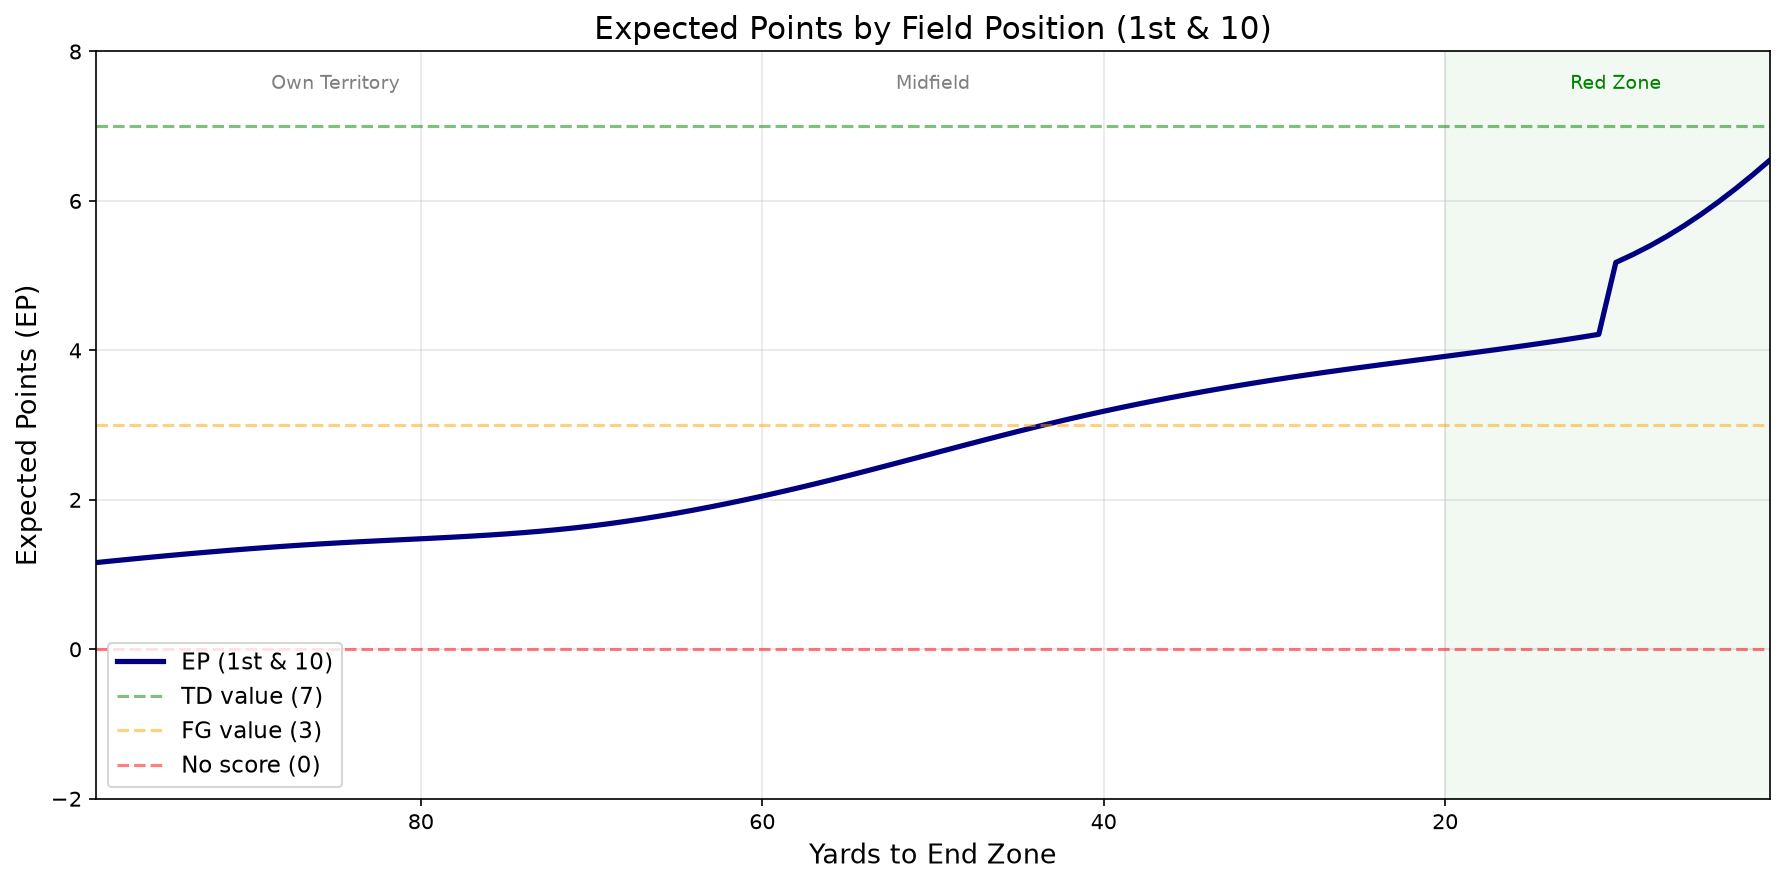


EP at key field positions (1st & 10):
 yardline_100       ep
            1 6.541405
            5 5.822069
           10 5.176991
           20 3.919947
           30 3.606676
           40 3.185463
           50 2.620135
           60 2.050130
           70 1.651193
           80 1.478995
           90 1.345930
           99 1.160895


In [29]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
import io
from IPython.display import Image

yardlines = np.arange(1, 100)

predict_df = pd.DataFrame({
    'dn':           1,
    'dist':         10,
    'yardline_100': yardlines,
    'series':       10,
    'goal_to_go':   0  # 1st and 10 is not goal to go except inside the 10
})

# Set goal_to_go = 1 where yardline_100 <= 10 (dist == yardline_100)
predict_df.loc[predict_df['yardline_100'] <= 10, 'goal_to_go'] = 1
predict_df.loc[predict_df['yardline_100'] <= 10, 'dist'] = predict_df.loc[
    predict_df['yardline_100'] <= 10, 'yardline_100'
]

predict_df['ep'] = gam.predict(predict_df[features])

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(predict_df['yardline_100'], predict_df['ep'],
        color='navy', linewidth=2.5, label='EP (1st & 10)')

#ax.scatter(predict_df['yardline_100'], predict_df['ep'],
#          color='navy', s=40, label='EP (1st & 10)')

ax.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='TD value (7)')
ax.axhline(y=3, color='orange', linestyle='--', alpha=0.5, label='FG value (3)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No score (0)')

ax.set_xlabel('Yards to End Zone', fontsize=13)
ax.set_ylabel('Expected Points (EP)', fontsize=13)
ax.set_title('Expected Points by Field Position (1st & 10)', fontsize=15)
ax.set_xlim(99, 1)
ax.set_ylim(-2, 8)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

ax.axvspan(0, 20, alpha=0.05, color='green')
ax.text(10, 7.5, 'Red Zone', ha='center', fontsize=9, color='green')
ax.text(50, 7.5, 'Midfield', ha='center', fontsize=9, color='gray')
ax.text(85, 7.5, 'Own Territory', ha='center', fontsize=9, color='gray')

plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image(buf.read()))
plt.close()

# Print key values
key_yardlines = [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]
key_df = predict_df[predict_df['yardline_100'].isin(key_yardlines)]
print("\nEP at key field positions (1st & 10):")
print(key_df[['yardline_100', 'ep']].to_string(index=False))

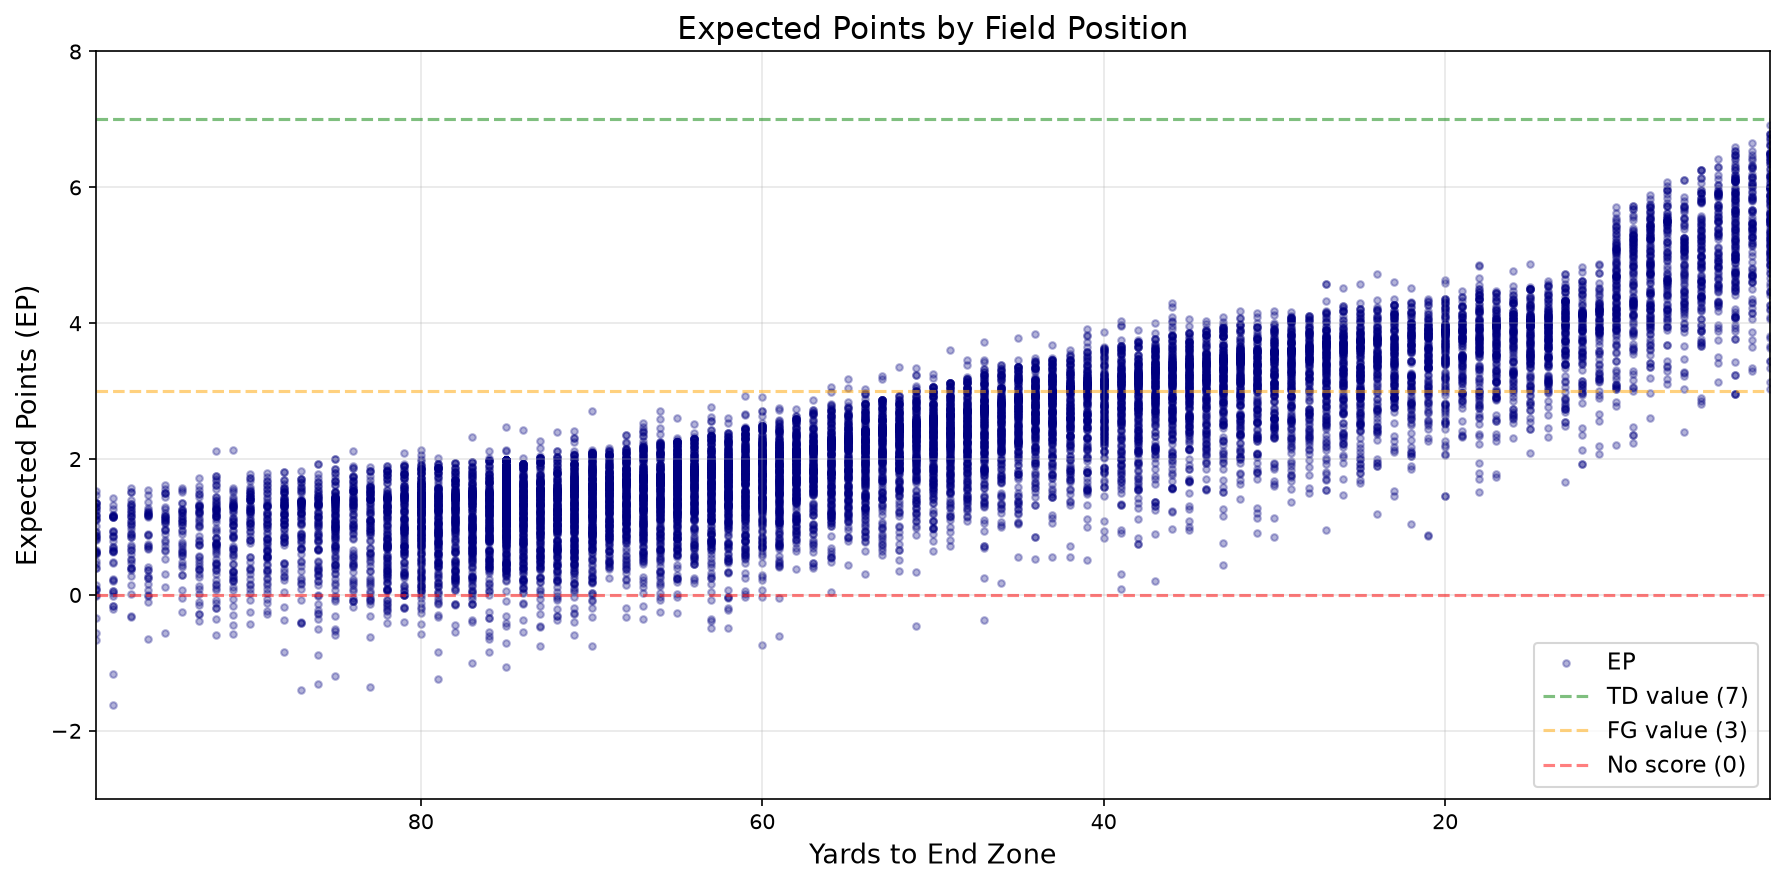

In [30]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(model_df['yardline_100'], model_df['ep'],
           color='navy', s=10, alpha=0.3, label='EP')

ax.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='TD value (7)')
ax.axhline(y=3, color='orange', linestyle='--', alpha=0.5, label='FG value (3)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='No score (0)')

ax.set_xlabel('Yards to End Zone', fontsize=13)
ax.set_ylabel('Expected Points (EP)', fontsize=13)
ax.set_title('Expected Points by Field Position', fontsize=15)
ax.set_xlim(99, 1)
ax.set_ylim(-3, 8)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format='png', dpi=150, bbox_inches='tight')
buf.seek(0)
display(Image(buf.read()))
plt.close()

Export to excel to use for analysis.

In [31]:
# =========================
# EXPORT TO EXCEL
# =========================

all_df.to_excel(PROCESSED_FILE, sheet_name="PlayList", index=False)
print("Exported successfully.")

Exported successfully.
